In [1]:
import random
import math
import matplotlib.pyplot as plt

In [2]:
def sigmoid(x):
    return 1 / (1 + math.exp(-x))
def dsigmoid(x):
    s = sigmoid(x)
    return s * (1-s)

X = [
    [1, 1, 1, 0, 1, 0, 0, 1, 0], #T
    [1, 1, 1, 0, 1, 0, 1, 1, 0], #J
    [1, 1, 1, 1, 0, 1, 1, 1, 1], #O
    [1, 1, 1, 1, 1, 0, 1, 1, 1], #S
    [1, 1, 1, 1, 0, 0, 1, 1, 1], #C
    [1, 1, 1, 0, 1, 0, 1, 1, 1], #I
]
y = [[ 1 if n==m else 0 for n in range(len(X))] for m in range(len(X))]
learning_rate = 0.1

ill = len(X[0])
h1ll = 7
h2ll = 7
oll = len(y[0])

weights_ih1 = [ [random.uniform(-1, 1) for i in range(ill)] for j1 in range(h1ll) ]
biases_h1 = [ random.uniform(-1, 1) for j1 in range(h1ll) ]

weights_h1h2 = [ [random.uniform(-1, 1) for j1 in range(h1ll)] for j2 in range(h2ll) ]
biases_h2 = [ random.uniform(-1, 1) for j2 in range(h2ll) ]

weights_h2o = [ [random.uniform(-1, 1) for j2 in range(h2ll)] for k in range(oll) ]
biases_o = [ random.uniform(-1, 1) for k in range(oll) ]

In [3]:
def predict(I):
    h1 = [
        sum( [ I[i] * weights_ih1[j1][i] for i in range(ill)] ) + biases_h1[j1] for j1 in range(h1ll)
    ]
    ah1 = [ sigmoid(h1[j1]) for j1 in range(h1ll) ]
    h2 = [
        sum( [ ah1[j1] * weights_h1h2[j1][j2] for j1 in range(h1ll)] ) + biases_h2[j2] for j2 in range(h2ll)
    ]
    ah2 = [ sigmoid(h2[j2]) for j2 in range(h2ll) ]
    z = [
        sum([ ah2[j2] * weights_h2o[k][j2] for j2 in range(h2ll) ]) + biases_o[k] for k in range(oll)
    ]
    output = [ sigmoid(z[k]) for k in range(oll) ]
    return h1, ah1, h2, ah2, z, output

Cost: 0.17212389752079746


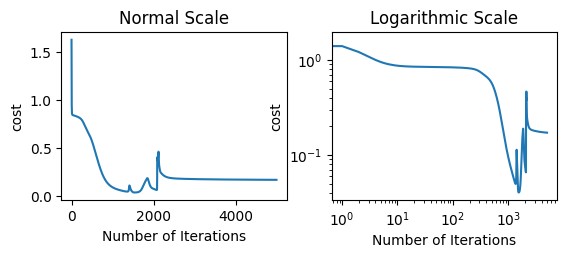

In [4]:
costHistory = []

cost = 1
count = 0
while cost > 0.0001 and count < 5000:
# for r in range(1000):
    costs = []
    for p in range(X.__len__()):
        I = X[p]
        E = y[p]

        h1, ah1, h2, ah2, z, output = predict(I)

        Cw_h2o = [ [ 2 * (output[k]-E[k]) * dsigmoid(z[k]) * ah2[j2] for j2 in range(h2ll) ] for k in range(oll) ]
        Cb_o = [ 2 * (output[k]-E[k]) * dsigmoid(z[k]) for k in range(oll) ]

        Cw_h1h2 = [ 
                    [ 
    2 * ah1[j1] * dsigmoid(h2[j2]) * sum([ (output[k]-E[k]) * dsigmoid(z[k]) * weights_h2o[k][j2] for k in range(oll)])
                    for j1 in range(h1ll)
                ] 
            for j2 in range(h2ll)
        ]
        Cb_h2 = [ 2 * dsigmoid(h2[j2]) * sum([ (output[k]-E[k]) * dsigmoid(z[k]) * weights_h2o[k][j2] for k in range(oll)]) for j2 in range(h2ll)]

        Cw_ih1 = [ 
                    [ 
    2 * I[i] * dsigmoid(h1[j1]) * sum([ (output[k]-E[k]) * dsigmoid(z[k]) * sum([weights_h2o[k][j2] * dsigmoid(h2[j2]) * weights_h1h2[j2][j1] for j2 in range(h2ll)]) for k in range(oll)])
                    for i in range(ill)
                ] 
            for j1 in range(h1ll)
        ]
        Cb_h1 = [ 2 * dsigmoid(h1[j1]) * sum([ (output[k]-E[k]) * dsigmoid(z[k]) * sum([weights_h2o[k][j2] * dsigmoid(h2[j2]) * weights_h1h2[j2][j1] for j2 in range(h2ll)]) for k in range(oll)]) for j1 in range(h1ll)]
        
        weights_h2o = [ [ weights_h2o[k][j2] - Cw_h2o[k][j2] * learning_rate for j2 in range(h2ll) ] for k in range(oll) ]
        biases_o = [ biases_o[k] - Cb_o[k] * learning_rate for k in range(oll) ]

        weights_h1h2 = [ [ weights_h1h2[j2][j1] - Cw_h1h2[j2][j1] * learning_rate for j1 in range(h1ll) ] for j2 in range(h2ll) ]
        biases_h2 = [ biases_h2[j2] - Cb_h2[j2] * learning_rate for j2 in range(h2ll) ]
        
        weights_ih1 = [ [ weights_ih1[j1][i] - Cw_ih1[j1][i] * learning_rate for i in range(ill)] for j1 in range(h1ll) ]
        biases_h1 = [ biases_h1[j1] - Cb_h1[j1] * learning_rate for j1 in range(h1ll) ]

        costs.append(sum([ math.pow(output[k]-E[k], 2) for k in range(oll) ]))

    cost = sum(costs)/len(costs)
    costHistory.append(cost)
    count+=1

print(f'Cost: {cost}')

plt.subplot(2, 2, 1)
plt.plot([i for i in range(len(costHistory))], costHistory)
plt.title('Normal Scale')
plt.xlabel('Number of Iterations')
plt.ylabel('cost')

plt.subplot(2, 2, 2)
plt.loglog([i for i in range(len(costHistory))], costHistory)
plt.title('Logarithmic Scale')
plt.xlabel('Number of Iterations')
plt.ylabel('cost')

plt.show()

In [5]:
c=0
t=0
accuracy=0

for i in range(100):
    # The full list of labels for all 6 patterns
    answer = ['T', 'J', 'O', 'S', 'C', 'I'] 
    
    # New/Extended list of test input templates
    test_inputs = [
        # 0: T template (Original)
        [random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0, 0.2), random.uniform(0.8, 1), random.uniform(0, 0.2), random.uniform(0, 0.2), random.uniform(0.8, 1), random.uniform(0, 0.2)],
        # 1: J template (Original)
        [random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0, 0.2), random.uniform(0.8, 1), random.uniform(0, 0.2), random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0, 0.2)],
        # 2: O template (Original)
        [random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0, 0.2), random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0.8, 1)],
        
        # 3: S template (Based on X pattern: [1, 1, 1, 1, 1, 0, 1, 1, 1])
        [random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0, 0.2), random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0.8, 1)],
        
        # 4: C template (Based on X pattern: [1, 1, 1, 1, 0, 0, 1, 1, 1])
        [random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0, 0.2), random.uniform(0, 0.2), random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0.8, 1)],
        
        # 5: I template (Based on X pattern: [1, 1, 1, 0, 1, 0, 1, 1, 1])
        [random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0, 0.2), random.uniform(0.8, 1), random.uniform(0, 0.2), random.uniform(0.8, 1), random.uniform(0.8, 1), random.uniform(0.8, 1)],
    ]
    
    v = random.randrange(3)
    test_input = test_inputs[v]
    
    h1, ah1, h2, ah2, z, o = predict(test_input)
    # print(o)
    prediction = o.index(max(o))
    c += 1 if prediction == v else 0
    t += 1
    # print(f'Predicted: {answer[prediction]}\nActual: {answer[t]}')

accuracy = c/t*100
print(f'Accuracy: {accuracy}%')

Accuracy: 64.0%
